In [ ]:

-- delete duplicate record using the rowid - the rowid is i
--ROWID is a pseudo-column in Oracle.It is not stored as a regular column.
--Every row automatically has a unique physical address.
delete from department d1  where d1.rowid> (select min(d2.rowid) from department d2 where
 d1.department_name=d2.department_name
 and
d1.department_id=d1.department_id)

-- in my sql we don't have rowid, instead of it we use inner join 
DELETE d1
FROM department d1
JOIN department d2
ON d1.department_name = d2.department_name
AND d1.id > d2.id;

--  in postgresql
DELETE FROM department d1
USING department d2
WHERE d1.department_name = d2.department_name
AND d1.id > d2.id;

In [ ]:
we delete the data from multiple table at a time by using join

delete t1, t2 from t1 inner join t2 where t1.id=t2.id and t2.id=t1.id

In [ ]:
- the self join example , to find out the employee name whose location is as similart to joe location

select e1.name from employee e1, employee e2 
where e1.location=e2.location
and e2.name='joe'

In [ ]:
-- the index position in oracle starts from 1 not from zero.

-- when we create a primary key for a table , the default index is created , and the index name is 'unique'

-- point to remeber- We have two tables and they have foregion key reference each other on different columns, , now how can i insert the data in two tables, - ans- first we have to disable the foregion key, and this should be not a design. (it is called circular reference)

Q. what is sequence - sequence is the database object that autogenerats the continuos unique number on a particular column. syntax- 
create sequence sequence_name

Q. what are the set operators available - union, union all, minus, intersect(common rows)

Q. whar are the differnce between set operators and joins ? joins- are used to select the column from two or table based on the logication relationship between the tables.
 (simple -A JOIN combines columns from two or more tables.Think horizontal combination. )

set operator- is to combine similar type of data from two or more tables.

(simply - A SET operator combines rows from two queries. Think vertical combination.)

-

-- -- Which is faster Union or Union all - >>> Ans - 
Union all is faster, because union is select -- all 
distinct rows from queries that means , the duplicate will be removed, - 
the process of removing the -- duplicates takes extra time ,
 that's why union is slower than union all.

In [ ]:
%sql
-- what is nested subquery - any query which is appers in the where clause is called nested subqueris.

/* what is inline view-? -  
Any suqbquery which appears in the from clause, is called as inline view
eg. 
    select * from sales s (
    select customerid from customer 
    where region= 'us-pacific'
    
    ) c 
    where s.custid=c.custid

*/

/*
what is scaler subquery - A subquery which appears in select clause or where cluase
and return only one row and columns (only one value), if it returns more than one row or columns database will throw and error

select customerid, total_amount
  ( select first_name 
  from customer 
   where c.customer_id=s.customer_id ) first_name 
   from sales s
*/


In [ ]:
%md
/*
what is view - a view is a virtual table based on the result set of query.
A view is a named SQL query stored in the database. It does not store data itself (except for materialized views). 
Whenever you query a view, 
the database executes the underlying SQL and returns the result.

view- store the query not the result

view always execute the latest query 
view provide the security, data abstraction, 
reusability

A standard view does not store data. It stores only the SQL query definition.
 Whenever a user queries the view, the database executes 
the underlying query and returns the latest data from the base tables.
*/ 


/* 

what is key preserved table?
A key preseverd table whose key like primary key or unique remains unique after perfomring a join 
-
 it means a key preserved table is table in a join where every primary key or unique key , appears at most once in the result
 eg. 
        SELECT e.emp_id,
            e.emp_name,
            d.dept_name
        FROM employee e
        JOIN department d
        ON e.dept_id = d.dept_id;

A key-preserved table is a table in a join whose primary key or unique key remains unique in the join result.
 In other words, rows from that table are not duplicated by the join. Oracle uses this 
 concept to determine whether a join view is updatable. If a table is not key preserved, 
updating its columns through the view can result in ORA-01779 because Oracle
 cannot uniquely map the updated row back to a single base table row."



In [ ]:
%md
![image_1782396296559.png](./image_1782396296559.png "image_1782396296559.png")

In [ ]:
%sql
what if the tables are delete , used by view - then what happened to the view- 
then all view will be invalid

Q- What is the force option on view - 
It create the view forcefully , even the select query is invalid. 
eg. - 
create force view v1 as select * from customer where region='us-west';
-- this is mostly used when the, underlying table is not created but still we want to create the view on different env.

In [ ]:
/*

what is shared lock and exclusive lock 
-shared lock- the lock applies on data item , where the data can be read , but transaction can't 
write into data 

-- exlcusive lock- can't read and can't write 

What is dead lock- when two or sessions waiting data from each other, two session data lock by 
each other . 
/*

In [ ]:
/*
what is savepoint ? 
- It is generally a marker within a transation, it allows for partial rollback, 
= we can create the savepoin in a transaction to mark different points
- it is for rollback, any point we got the error , we can easily point to the previous state by using
savepoinnt 

Q- What is table fragementation- 
, when we delete data from table, the deleted data is not reuse immediatly, 
it create the holes in table, which cause table fragementation.

In [ ]:
/*
what is difference between the logical model

- in logical model, we represent the database in terms of logical model
(entity and relationship between them)

- physical mode, - we represent the database in tems of physical model
(table and constraints)

*/

### what are virtual columns - In virtual columns, the columns values are derived at run time and they 
are not stored on disc. as normal column stored on disc

eg.-
create table employee(
    name varchar2(10 char),
    salary Number,
    salar1 as round((salary*2/10),5)

)

can we apply index on virtual columns - yes we can 
can we update the virutal columns - No, because it derives at run time. and data is not stored 
on disc


can we create constraints on it- yes 
*/ 


### default index and all
- index are seperate data structure that are used for fast retrival of data from table, 
by default index is- b- tree index 
- types- btree, bitmap, bitmapjoin, hash index, function based index

when to use the function based index- 
When we use function on a column in regular basis to fetch data from database, it cause the performence issue,
to imigiate that issue, we create the  function based index - for that particular column 
eg. - create index index_name on table_name (upper(column_name));



Q- Whar is composite index- the index is create on two or more columns are called composite index
eg. create index index_name on table_name (column1, column2)

imp - How does indexs are stored?
- Indexes are stored in the form of b-tree structure



### what is partition and partitioning on table
A partition is a logical division of a large table into smaller, manageable pieces.


what is partitioning  ? 
Table partitioning is the process of dividing one large table into multiple 
smaller physical partitions based on a partition key, 
while presenting them as a single logical table to users.

how to drop a partiotion 
ALTER TABLE sales
DROP PARTITION p2020; , where partiton on year base, here we delete teh 2020 partition

how to rebuild partiton index 
ALTER INDEX idx_sales
REBUILD PARTITION p2025;


When does Partitioning Help?

If the query filters on the partition key.

Example

WHERE sale_date='2025-01-10'

eg. 

CREATE TABLE sales
(
    sale_id NUMBER,
    sale_date DATE,
    amount NUMBER
)

PARTITION BY RANGE(sale_date)
(
PARTITION p2024 VALUES LESS THAN (DATE '2025-01-01'),

PARTITION p2025 VALUES LESS THAN (DATE '2026-01-01')
);

types of partitioning 
-1- range partition ( most commonly used)
2- list partition
3- hash partition
4- composite partition
5- interval partition





### What is exchange partition ? 
- Partition Exchange is an Oracle feature that swaps the data of a partition in a partitioned table with a standalone (non-partitioned) table without physically moving the rows.

- The partition exchange operation is performed in two steps:

- Step 1: Create a non-partitioned table with the same schema as the partitioned table.
- Step 2 - first load the new data into non partitioned stg table. 
- Step 3- Perform the swap with stg table, this will move the data from stg table to partitioned table. 
sytanx- alter table table_name exchange partition (partition_spec) with table stg_table_name;
- It is also called swapping of pointers. we are not copying the data.
- Its only movment of metadata

 eg. with validationn 
 ALTER TABLE sales
EXCHANGE PARTITION p2025
WITH TABLE stage_sales
WITH VALIDATION;



### What is materialize view, - 
- A materialized view is a physical copy of the result of a query that can be refreshed periodically or on demand to stay synchronized with the base tables.

-A Materialized View is a database object that stores the result of a query physically, unlike a normal view which stores only the SQL definition. It is primarily used to improve the performance of expensive queries involving joins, aggregations, and large datasets. Since it stores data, it can become stale when the base tables change, so Databases provide refresh mechanisms such as Complete Refresh, Fast Refresh, and refresh modes like ON COMMIT or ON DEMAND."

| View                       | Materialized View                   |
| -------------------------- | ----------------------------------- |
| Doesn't store rows         | Stores rows                         |
| Virtual                    | Physical                            |
| Executes query every time  | Reads stored data                   |
| Always latest data         | Can become stale until refreshed    |
| No extra storage           | Requires storage                    |
| Slower for complex queries | Faster for repeated complex queries |



- many developers say, it is a A snapshot of data

at one point in time. ()


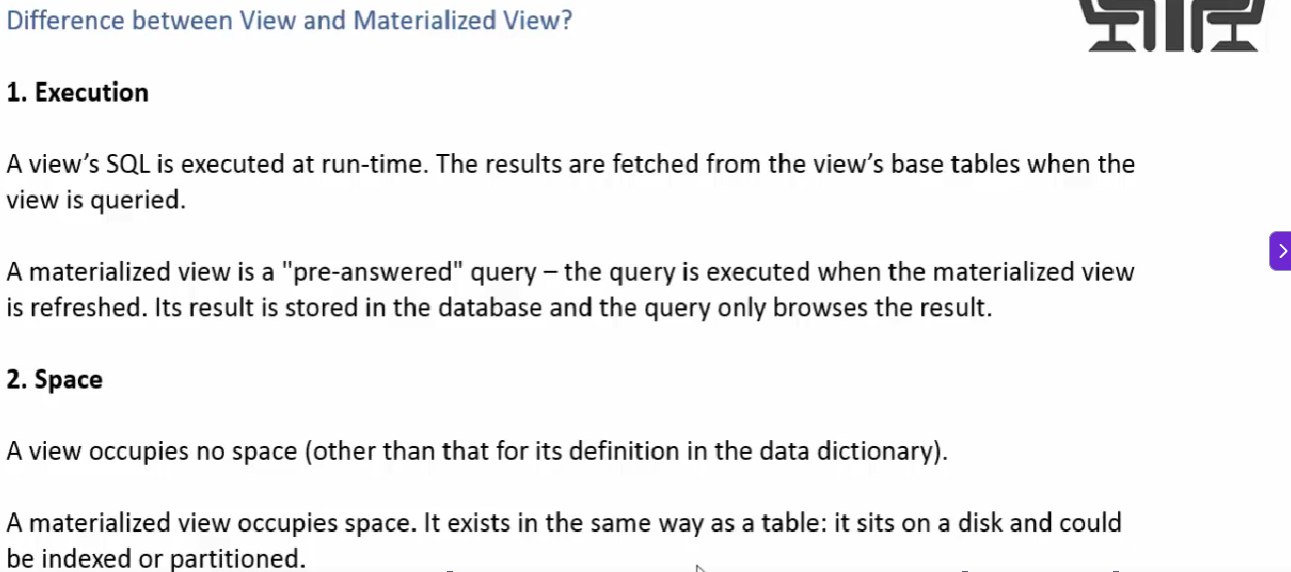
materialized views are so valuable for reporting, dashboards, and data warehouse
periodically analysis of data.
- Also useful for replication of data between servers.


- Materialize View refresh - 

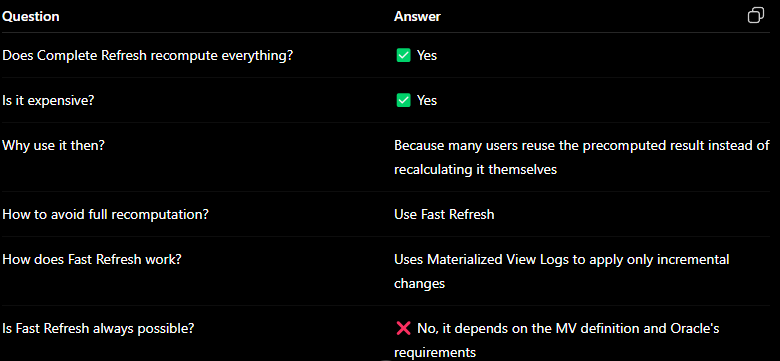
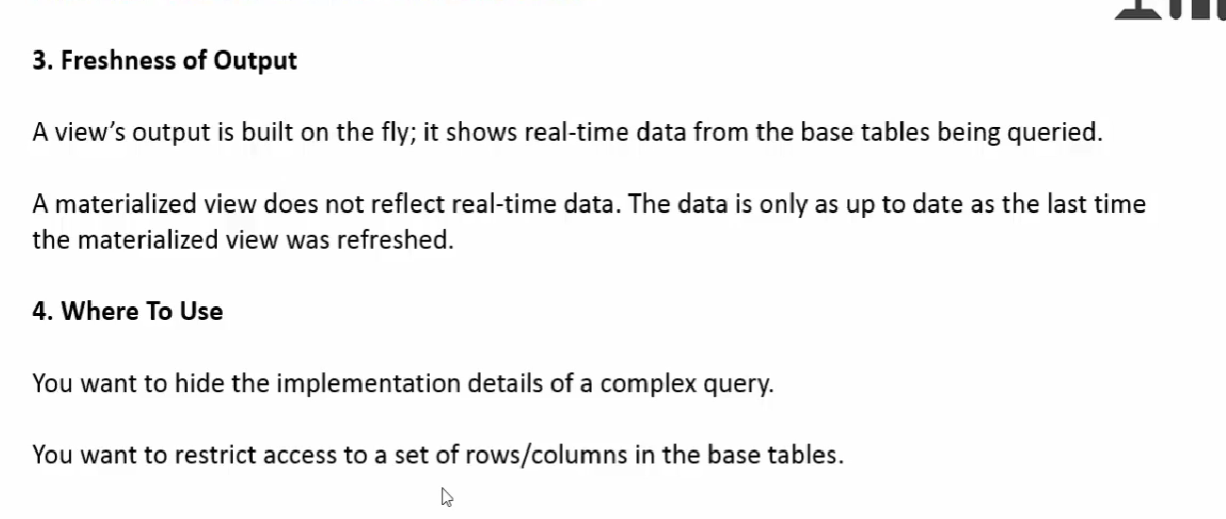
Refresh Strategy (How)
   - FAST
    -COMPLETE
     -FORCE

Refresh Timing (When)
    ON COMMIT
    ON DEMAND
    ON SCHEDULE


Note- 
For a materialized view to support FAST REFRESH, database generally requires:

- Materialized View Logs on the base tables.
- A query that is eligible for fast refresh.
- Other Oracle restrictions to be satisfied.
*/


/* 
what is materialize view log ?

A Materialized View Log is a database object/table that records changes (INSERT, UPDATE, DELETE) and primarykey/rowid of rows that madec change in master table so that Oracle can perform FAST REFRESH without scanning the entire base table.

what can be contains in  view log and how to create?

How do we create an MV Log?
CREATE MATERIALIZED VIEW LOG
ON employee
WITH PRIMARY KEY;

or

CREATE MATERIALIZED VIEW LOG
ON employee
WITH ROWID;

or can be contain the timestamp 
and dml type. 
*/

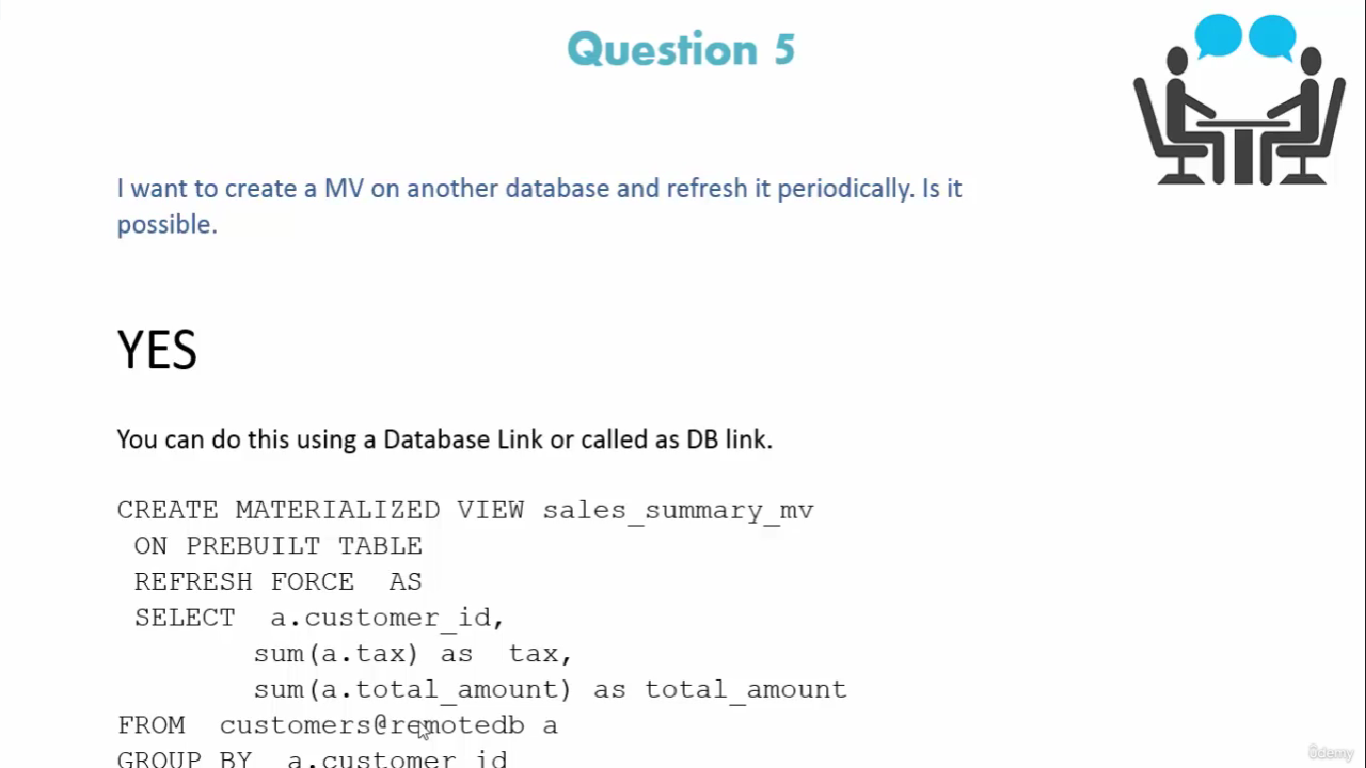
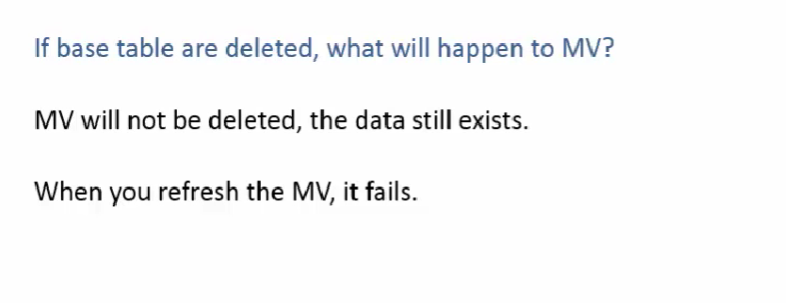
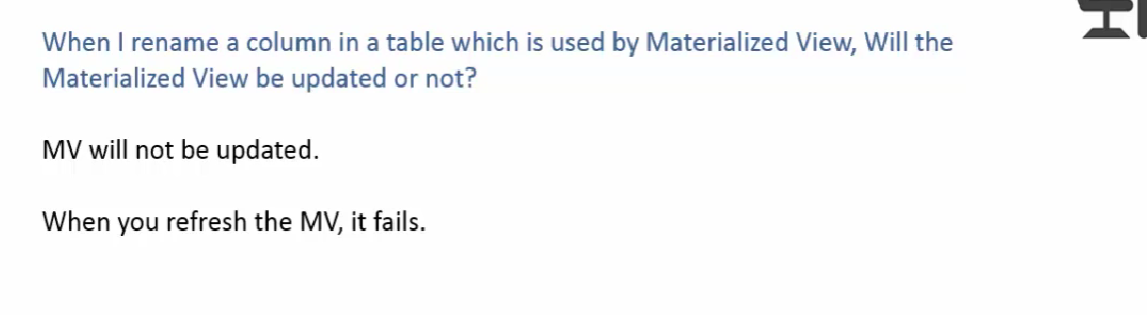

In [ ]:
+%sql
/*
What is Query Rewrite 
Query Rewrite is an Oracle optimizer feature that automatically redirects a user's query to an appropriate Materialized View instead of executing the original query against the base tables. If the Materialized View already contains the required results and is eligible for use, Oracle rewrites the execution plan to use the Materialized View, reducing query execution time significantly. The user's SQL statement remains unchanged; only the execution plan is modified.

CREATE MATERIALIZED VIEW mv_dept_salary
REFRESH FAST ON COMMIT
ENABLE QUERY REWRITE
AS
SELECT department,
       SUM(salary) total_salary
FROM employee
GROUP BY department;

ALSO THE USER QUERY SHOULD BE VALID eg.

*User asks

SELECT country,
       SUM(amount)
FROM sales
GROUP BY country;
--Oracle uses MV.
=---------------------------------------
User asks

SELECT customer_name,
       SUM(amount)
FROM sales
GROUP BY customer_name;

The MV doesn't contain customer information.
Oracle must read SALES table

*/


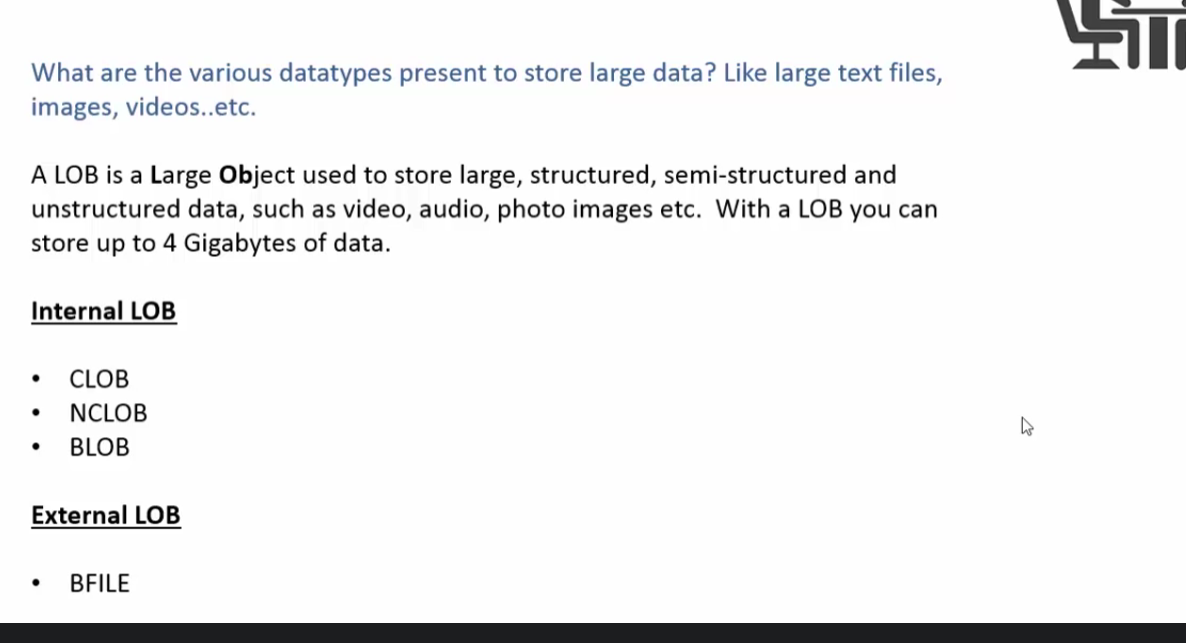

CLOB, NCLOD,BLOB- 
CLOB (Character Large Object)

Stores very large text.

Examples:

Books
Articles
HTML
XML
JSON
Source code
Email body

#----------------------------------------------------------
NCLOB (National )

Very similar to CLOB.

Difference:

Stores Unicode (National Character Set).

Suppose you store

English
Hindi
Japanese
Chinese
Arabic
Greek
Russian
etc.

#----------------------------------------------------------
BLOB (Binary Large Object)

Stores very large binary data.

Examples:

Images
Videos
Music
Archives
etc.
